# Floating Point: How Computers Store Numbers (and Where It Surprises You)

**This notebook teaches floating-point numbers from scratch — no prior exposure is assumed.**

The number $\pi = 3.14159265\ldots$ has infinitely many digits, but a computer has only finite memory, so it must **approximate**. It does this in **binary** (base 2), and for most decimals the binary form never ends — so the stored value is slightly off. Usually that is harmless, but sometimes it bites: `0.1 + 0.2` is not exactly `0.3`, and long sums can quietly stop growing. This notebook shows *why*, starting from how numbers are written in binary.

## Learning objectives

- Explain why a computer must approximate most numbers, and why it uses **base 2**.
- Convert between decimal and binary, and see why $0.1$ has **no exact** binary form.
- Define **machine epsilon** and compare floats with a **tolerance** instead of `==`.
- Watch a long sum **stop changing** because of finite precision.
- Distinguish **absorption** (a small number lost beside a big one) from **catastrophic cancellation** (two nearly-equal numbers subtracted), and rewrite arithmetic to avoid the second.

## Background

A computer stores a number as `sign × mantissa × base^exponent` (for example $25.625 = +\,1.1001101 \times 2^{4}$ in binary). It uses **base 2** because a transistor reliably holds just two states — off/on, i.e. $0/1$ — whereas base 10 would need ten distinct states. (Humans use base 10 only because we have ten fingers.)

Because only finitely many bits are stored, most numbers are rounded. **Machine epsilon** $\varepsilon$ is the smallest number for which the computer still sees $1 + \varepsilon > 1$; anything smaller is lost when added to 1. So you should never compare computed floats with `==` — instead test $|a - b| < \text{tol}$.

## This notebook covers

1. Why computers approximate numbers.
2. Numbers in binary (decimal ↔ binary).
3. Why $0.1$ is not exact — and $0.1 + 0.2 \ne 0.3$.
4. Machine epsilon.
5. Comparing with a tolerance.
6. A sum that stops changing.
7. Absorption: losing a small number next to a big one.
8. Catastrophic cancellation, and how to avoid it.

**Prerequisites:** none — this notebook starts from scratch.

**Dataset:** none — numerical demonstrations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

## 1. Why computers approximate numbers

Numbers like $\pi$ have infinitely many digits, but memory is finite, so a computer keeps only a fixed number of them and rounds the rest away. A `float` holds about **15–16 significant decimal digits** — plenty for most work, but not exact.

In [2]:
print("math.pi stored as a float:", math.pi)
print("pi really begins:          3.14159265358979323846...")

math.pi stored as a float: 3.141592653589793
pi really begins:          3.14159265358979323846...


## 2. Numbers in binary

Computers store numbers in **binary** (base 2), using only the digits 0 and 1. Converting a number to binary has two halves.

**Whole part — repeated division by 2.** Divide by 2, write the remainder, repeat; read the remainders bottom-to-top. For $25$: this gives $11001_2$.

**Fractional part — repeated multiplication by 2.** Multiply by 2, write the integer part (0 or 1), keep the leftover fraction, repeat; read top-to-bottom. For $0.625$: this gives $0.101_2$.

Together, $25.625_{10} = 11001.101_2$. Here are both algorithms as simple loops.

In [3]:
# --- whole part: 25 -> binary, by repeated division by 2 ---
n = 25
whole_bits = []
while n > 0:
    remainder = n % 2          # 0 or 1
    whole_bits.append(remainder)
    n = n // 2                 # integer divide
whole_bits.reverse()           # remainders are read bottom-to-top

print("25 in binary:", "".join(str(b) for b in whole_bits), " (check:", bin(25), ")")

25 in binary: 11001  (check: 0b11001 )


In [4]:
# --- fractional part: 0.625 -> binary, by repeated multiplication by 2 ---
frac = 0.625
frac_bits = []
for step in range(10):
    frac = frac * 2
    bit = int(frac)            # the integer part, 0 or 1
    frac_bits.append(bit)
    frac = frac - bit          # keep only the leftover fraction
    if frac == 0:              # stop once nothing is left
        break

print("0.625 in binary: 0.", "".join(str(b) for b in frac_bits), sep="")

0.625 in binary: 0.101


$0.625$ finished cleanly after three bits because it happens to be a sum of halves ($\tfrac12 + \tfrac18$). The next section shows a decimal that never finishes.

## 3. Why 0.1 is not exact — and 0.1 + 0.2 ≠ 0.3

Run the very same "multiply by 2" algorithm on $0.1$ and it **never terminates** — the bits fall into a repeating pattern that goes on forever. Since the computer must stop after a fixed number of bits, it stores only a rounded version of $0.1$. The same is true of $0.2$ and $0.3$, and the small errors do not cancel — so `0.1 + 0.2` comes out slightly wrong.

In [5]:
# Apply the fraction-to-binary algorithm to 0.1 -> it repeats forever.
frac = 0.1
bits = []
for step in range(20):          # just show the first 20 bits
    frac = frac * 2
    bit = int(frac)
    bits.append(bit)
    frac = frac - bit

print("0.1 in binary starts: 0.", "".join(str(b) for b in bits), "...", sep="")

0.1 in binary starts: 0.00011001100110011001...


In [6]:
print("0.1 + 0.2      =", 0.1 + 0.2)
print("0.1 + 0.2 == 0.3 ?", 0.1 + 0.2 == 0.3)
print("to 17 digits: " + format(0.1 + 0.2, ".17f"))

0.1 + 0.2      = 0.30000000000000004
0.1 + 0.2 == 0.3 ? False
to 17 digits: 0.30000000000000004


The sum is $0.30000000000000004$, not $0.3$ — the leftover rounding error from storing $0.1$, $0.2$, and $0.3$ in binary.

## 4. Machine epsilon

**Machine epsilon** $\varepsilon$ is the smallest number for which the computer still sees $1 + \varepsilon > 1$. Add something smaller than that to $1$ and it vanishes. NumPy reports it with `np.finfo`.

In [7]:
eps = np.finfo(float).eps
print("machine epsilon =", eps)

print("1.0 + eps     == 1.0 ?", 1.0 + eps == 1.0)       # just big enough to matter
print("1.0 + eps/2   == 1.0 ?", 1.0 + eps / 2 == 1.0)   # too small: lost

machine epsilon = 2.220446049250313e-16
1.0 + eps     == 1.0 ? False
1.0 + eps/2   == 1.0 ? True


## 5. Compare with a tolerance

Because computed floats carry tiny errors, never test them with `==`. Instead check whether they are *close* — within a small tolerance.

In [8]:
a = 0.1 + 0.2
b = 0.3

tolerance = 1e-9
print("exact equality a == b:  ", a == b)
print("close within tolerance: ", abs(a - b) < tolerance)

exact equality a == b:   False
close within tolerance:  True


## 6. A sum that stops changing

The **harmonic series** $\sum_{n=1}^{\infty} \tfrac{1}{n} = 1 + \tfrac12 + \tfrac13 + \cdots$ is famous for **diverging** — in exact mathematics its total grows to infinity. But on a computer it does **not**: as the running total grows, each new term $\tfrac1n$ eventually becomes smaller than machine epsilon *relative to the total*, so adding it changes nothing and the sum **freezes**.

To see the freeze quickly we use **32-bit** floats (a bigger epsilon). We add terms until the total stops changing — a simple loop.

In [9]:
# Add 1 + 1/2 + 1/3 + ... in 32-bit precision until it stops changing.
total = np.float32(0.0)
previous_total = np.float32(-1.0)

n = 1
snapshots = []                    # record a few points for the plot
while total != previous_total:
    previous_total = total
    total = total + np.float32(1.0) / np.float32(n)   # add the next term 1/n
    if n % 5000 == 0:
        snapshots.append(float(total))
    n = n + 1

print("the harmonic sum froze after", n, "terms")
print("frozen value =", float(total), "(mathematically it should grow to infinity)")

the harmonic sum froze after 2097153 terms
frozen value = 15.403682708740234 (mathematically it should grow to infinity)


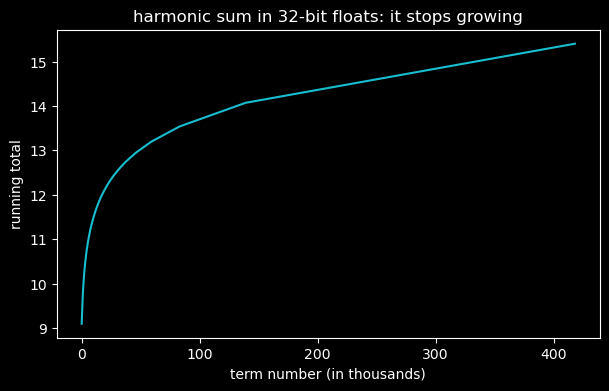

In [10]:
# --- graphics: show the running total flatten out (mechanics only) ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(snapshots, color="tab:cyan")
ax.set_xlabel("term number (in thousands)")
ax.set_ylabel("running total")
ax.set_title("harmonic sum in 32-bit floats: it stops growing")
plt.show()

The curve climbs and then goes flat: once $\tfrac1n$ dropped below the gap between representable numbers near the total, every further term was lost. A sum that is infinite in mathematics becomes finite on a computer.

## 7. Absorption: losing a small number next to a big one

Adding a small number to a very large one can lose the small number **entirely** — it is smaller than the gap between representable values that far out. Here, adding $1$ to $10^{16}$ and then subtracting $10^{16}$ should give $1$, but the $1$ has vanished.

This is called **absorption**: the small value was swallowed by the large one. It is the same effect as the frozen harmonic sum in section 6, seen in a single line of arithmetic.

In [11]:
big = 1e16
print("(big + 1) - big =", (big + 1) - big)   # hoped for 1.0

(big + 1) - big = 0.0


## 8. Catastrophic cancellation

Absorption loses a small number next to a big one. The opposite arrangement is just as dangerous: **subtracting two numbers that are nearly equal**. Both are stored to about 16 significant digits, but if the first 12 of those digits agree, they cancel — and the answer is left resting on only the last few digits, which are exactly the ones the rounding error lives in. The leading digits were correct; the ones that survive may not be.

This is **catastrophic cancellation**, and it is the more insidious of the two, because the result still *looks* like a perfectly ordinary number.

Watch it happen. The expression

$$\frac{1 - \cos x}{x^{2}}$$

approaches $\tfrac12$ as $x \to 0$ — that is its exact mathematical limit. But as $x$ shrinks, $\cos x$ gets closer and closer to $1$, so $1 - \cos x$ is a subtraction of two nearly-equal numbers.

In [12]:
# (1 - cos x) / x^2 has the exact limit 1/2 as x -> 0.
# Watch the computed value get BETTER, then fall apart.
print(f"{'x':>8} {'(1 - cos x) / x^2':>22}")
for x in [1e-1, 1e-2, 1e-4, 1e-6, 1e-8]:
    print(f"{x:8.0e} {(1 - math.cos(x)) / x**2:22.12f}")

print(f"\nthe exact limit is {0.5}")
print(f"at x = 1e-8, cos(x) rounds to exactly {math.cos(1e-8)}, so 1 - cos(x) = {1 - math.cos(1e-8)}")

       x      (1 - cos x) / x^2
   1e-01         0.499583472197
   1e-02         0.499995833347
   1e-04         0.499999996961
   1e-06         0.500044450291
   1e-08         0.000000000000

the exact limit is 0.5
at x = 1e-8, cos(x) rounds to exactly 1.0, so 1 - cos(x) = 0.0


Read that column top to bottom. The value closes in on $0.5$ nicely at first, then **turns around and gets worse**, and at the smallest $x$ it collapses to $0$ — because by then $\cos x$ has rounded to exactly $1.0$ and the numerator is exactly zero.

Nothing warned us. There was no error, no warning, no `nan` — just a confidently wrong number.

The fix is usually to **rewrite the arithmetic so the subtraction never happens**. The identity $1 - \cos x = 2\sin^2(x/2)$ does it here: no near-equal subtraction, so no cancellation.

In [13]:
# the same quantity, rewritten so nothing near-equal is ever subtracted
print(f"{'x':>8} {'(1 - cos x) / x^2':>22} {'2 sin^2(x/2) / x^2':>22}")
for x in [1e-1, 1e-2, 1e-4, 1e-6, 1e-8]:
    naive = (1 - math.cos(x)) / x**2
    safe = 2 * math.sin(x / 2)**2 / x**2
    print(f"{x:8.0e} {naive:22.12f} {safe:22.12f}")

       x      (1 - cos x) / x^2     2 sin^2(x/2) / x^2
   1e-01         0.499583472197         0.499583472197
   1e-02         0.499995833347         0.499995833347
   1e-04         0.499999996961         0.499999999583
   1e-06         0.500044450291         0.500000000000
   1e-08         0.000000000000         0.500000000000


The right-hand column holds $0.5$ all the way down. Same mathematics, different arithmetic, completely different accuracy — which is the whole lesson of this section.

You will meet this exact effect again in Unit 3: a numerical derivative divides $f(x+h) - f(x)$ by a tiny $h$, and that numerator is a subtraction of two nearly-equal numbers. It is why making $h$ smaller eventually makes the answer *worse* (`U3-4_NumericalDerivatives-1_FiniteDifference`).

## 9. Summary

- Computers store numbers in **binary** with finite precision, so most decimals (like $0.1$) are only **approximate** — which is why `0.1 + 0.2` is not exactly `0.3`.
- Any number's whole part converts to binary by repeated division by 2, its fraction by repeated multiplication by 2.
- **Machine epsilon** is the smallest amount that still changes $1$; compare floats with a **tolerance**, never `==`.
- Finite precision can make a long sum **freeze** — even the harmonic series, which is infinite in exact math, stops growing on a computer.
- **Absorption** loses a small number added to a much larger one.
- **Catastrophic cancellation** is the reverse — subtracting two nearly-equal numbers throws away the digits that agreed and leaves the answer resting on rounding error. It fails *silently*, and the cure is to rewrite the arithmetic so the subtraction never happens.

Next: linear algebra — vectors, matrices, and the systems they solve (`U2-1_Systems-1_GeometryOfSolutions`).